# Demographic predictors of birth counts in US counties from 2011-2020

In this notebook we will explore predictors of natality, defined here as birth count per county/year, for a subset of US counties between 2011 and 2020.  

In [2]:
import pandas as pd
import numpy as np
from prep import births, demog, pop, na, age_groups, rucc, adi
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

View some of the raw data:

In [3]:
births.head()

,County,FIPS,Births,year
0,"Baldwin County, AL",01003,2157.0,2011
1,"Calhoun County, AL",01015,1418.0,2011
2,"Etowah County, AL",01055,1173.0,2011
3,"Jefferson County, AL",01073,8916.0,2011
4,"Lee County, AL",01081,1536.0,2011


In [4]:
pop.head()

,FIPS,Population
0,01001,56943
1,01003,209832
2,01005,26304
3,01007,22652
4,01009,58197


In [5]:
adi.head()

FIPS5
01001    73.0
01003    53.5
01005    92.0
01007    84.0
01009    76.0
Name: ADI_NATRANK, dtype: float64

In [6]:
rucc.head()

,FIPS,RUCC_2013
0,01001,2.0
1,01003,3.0
2,01005,6.0
3,01007,1.0
4,01009,1.0


In [7]:
demog.head()

,A_H_F_0,A_H_F_1,A_H_F_2,A_H_F_3,A_H_F_4,A_H_F_5,A_H_F_6,A_H_F_7,A_H_F_8,A_H_F_9,...,W_N_M_10,W_N_M_11,W_N_M_12,W_N_M_13,W_N_M_14,W_N_M_15,W_N_M_16,W_N_M_17,W_N_M_18,W_N_M_19
FIPS,,,,,,,,,,,,,,,,,,,,,
01001,0,1,1,3,2,0,0,1,4,2,...,1608,1633,1540,1243,1074,790,586,397,180,56
01003,3,3,8,5,4,2,2,1,2,3,...,5911,6141,6263,6109,6099,4706,3185,2037,1031,419
01005,1,1,0,0,2,1,3,0,0,0,...,484,469,472,468,464,385,243,172,63,27
01007,0,2,0,0,1,0,1,0,2,0,...,656,725,605,528,503,350,241,129,75,20
01009,1,2,2,3,3,2,3,2,2,3,...,1852,1901,1859,1688,1573,1181,807,488,209,90


Create a dataframe for modeling.  Merge the birth data with population and RUCC data.

In [8]:
da = pd.merge(births, pop, on="FIPS", how="left")
da = pd.merge(da, rucc, on="FIPS", how="left")
da = pd.merge(da, adi, left_on="FIPS", right_on="FIPS5", how="left")

Population will be used as an offset below, so we log it here.

In [9]:
da["logPop"] = np.log(da["Population"])
da["logADINatRank"] = np.log(1 + da["ADI_NATRANK"])
da = da.dropna()

It's not always essential to center quantitative variables, but it makes it easier to interpret their effects, especially when interactions are used.

In [10]:
print(da["year"].mean())
da["yearc"] = da["year"] - da["year"].mean()
da["logPopc"] = da["logPop"] - da["logPop"].mean()
da["RUCC_2013c"] = da["RUCC_2013"] - da["RUCC_2013"].mean()
da["logADINatRank"] = da["logADINatRank"] - da["logADINatRank"].mean()
da["logADINatRankZ"] = da["logADINatRank"] / da["logADINatRank"].std()

2015.602383531961


One point that we will focus on below is the extent to which urbanicity (RUCC) and/or adversity (ADI) predict natality (after controlling for population size).  RUCC and ADI are related, but this does not mean that we cannot attempt to disentangle their roles in the regression.  The plot below giv

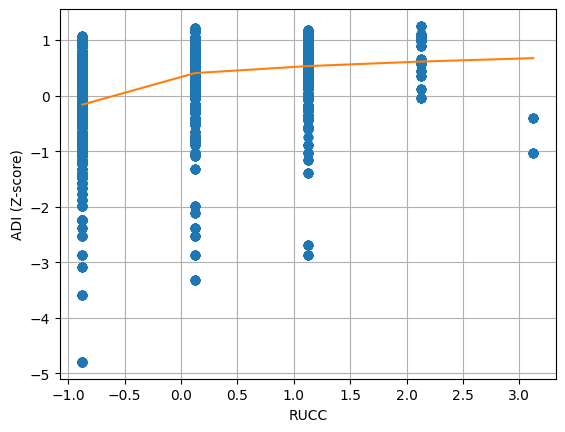

In [11]:
px = da[["RUCC_2013c", "logADINatRankZ"]]
lm = lowess(px["logADINatRankZ"], px["RUCC_2013c"])
plt.plot(px["RUCC_2013c"], px["logADINatRankZ"], "o")
plt.xlabel("RUCC")
plt.ylabel("ADI (Z-score)")
plt.plot(lm[:, 0], lm[:, 1])
plt.grid(True)

## Scaling by population size and offsets

It is natural to expect a 1-1 scaling between total population size and the number of births.  That is, all else equal we would expect two counties that differ by a factor of two in population size to differ by a factor of two in natality.  To assess this, we can make a scatterplot of the birth count versus the population size in log-space.  Under the expected 1-1 scaling, the slope of this line should be close to 1.

In [12]:
da = da.sort_values(["FIPS", "year"])
da.head()

,County,FIPS,Births,year,Population,RUCC_2013,ADI_NATRANK,logPop,logADINatRank,yearc,logPopc,RUCC_2013c,logADINatRankZ
0,"Baldwin County, AL",01003,2157.0,2011,209832,3.0,53.5,12.254062,0.152251,-4.602384,-0.332425,1.124052,0.265577
524,"Baldwin County, AL",01003,2109.0,2012,209832,3.0,53.5,12.254062,0.152251,-3.602384,-0.332425,1.124052,0.265577
1048,"Baldwin County, AL",01003,2160.0,2013,209832,3.0,53.5,12.254062,0.152251,-2.602384,-0.332425,1.124052,0.265577
1572,"Baldwin County, AL",01003,2244.0,2014,209832,3.0,53.5,12.254062,0.152251,-1.602384,-0.332425,1.124052,0.265577
2150,"Baldwin County, AL",01003,2344.0,2015,209832,3.0,53.5,12.254062,0.152251,-0.602384,-0.332425,1.124052,0.265577


np.float64(1.031047058498305)

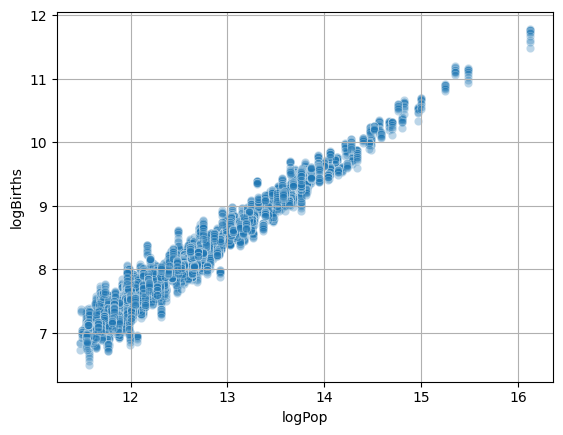

In [13]:
da["logBirths"] = np.log(da["Births"])
sns.scatterplot(da, x="logPop", y="logBirths", alpha=0.3)
plt.grid(True)
b = np.cov(da["logPop"], da["logBirths"])[0, 1] / np.var(da["logPop"])
b

## Assessing the variance structure and mean/variance relationships

Since we have 10 years of data for each county, we can treat these as replicates to estimate the mean and variance within each county (over the 10 years covered by the dataset).  This is one way for us to assess the mean/variance relationship.

In [14]:
mv = births.groupby("FIPS")["Births"].agg([np.mean, np.var])
lmv = np.log(mv)
mv

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_15716\401195481.py:1: FutureWarning: The provided callable <function mean at 0x0000019F4444A5C0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  mv = births.groupby("FIPS")["Births"].agg([np.mean, np.var])
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_15716\401195481.py:1: FutureWarning: The provided callable <function var at 0x0000019F4444A840> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  mv = births.groupby("FIPS")["Births"].agg([np.mean, np.var])


,mean,var
FIPS,,
01003,2249.400000,6699.600000
01015,1335.600000,3090.711111
01055,1190.100000,804.100000
01069,1323.714286,751.904762
01073,8650.800000,100633.288889
...,...,...
55117,1237.000000,3276.222222
55127,961.571429,6687.952381
55131,1308.200000,3390.400000


Regress log variance on log mean

In [15]:
mr = sm.OLS.from_formula("var ~ mean", lmv).fit()
print(mr.summary())

                            OLS Regression Results                            
Dep. Variable:                    var   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     2042.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):          7.38e-192
Time:                        14:31:58   Log-Likelihood:                -735.05
No. Observations:                 580   AIC:                             1474.
Df Residuals:                     578   BIC:                             1483.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.4898      0.338    -16.231      0.0

Plot the log variance against the log mean.  If variance = phi * mean, then log(variance) = log(phi) + log(mean), i.e. the slope is 1 and the intercept is log(phi).  If variance = phi * mean^a then log(variance) = log(phi) + a * log(mean).

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_15716\2038067669.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axline((8, mr.params[0]+8*mr.params[1]), slope=mr.params[1], color="orange")


Text(0, 0.5, 'Log variance')

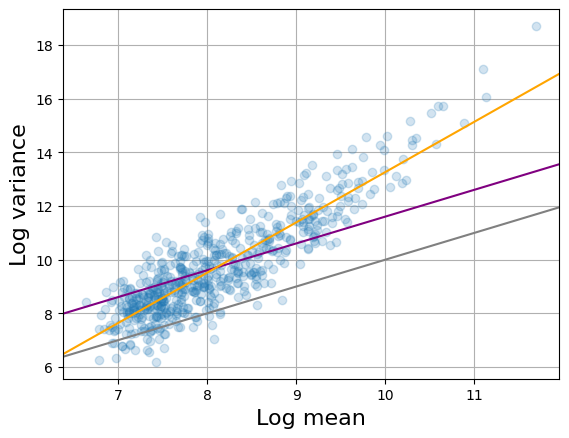

In [16]:
plt.clf()
plt.grid(True)
plt.plot(lmv["mean"], lmv["var"], "o", alpha=0.2, rasterized=True)
plt.axline((8, 8), slope=1, color="grey")
plt.axline((lmv["mean"].mean(0), lmv["var"].mean(0)), slope=1, color="purple")
plt.axline((8, mr.params[0]+8*mr.params[1]), slope=mr.params[1], color="orange")
plt.xlabel("Log mean", size=16)
plt.ylabel("Log variance", size=16)

## Urbanicity and time trends as predictors of natality

Below we fit a GLM, which is not appropriate since we have repeated measures on counties.  Due to the repeated measures, the uncertainty assessments (standard errors, p-values, confidence intervals, score tests) will be invalid, but the point estimates of the coefficients are still meaningful.

In [17]:
fml = "Births ~ logPop + RUCC_2013 + logADINatRankZ"
m0 = sm.GLM.from_formula(fml, family=sm.families.Poisson(), data=da)
r0 = m0.fit() # Poisson
r0x = m0.fit(scale="X2") # Quasi-Poisson
r0x.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 Births   No. Observations:                 5538
Model:                            GLM   Df Residuals:                     5534
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          121.58
Method:                          IRLS   Log-Likelihood:                -2950.1
Date:                Mon, 09 Feb 2026   Deviance:                   6.6212e+05
Time:                        14:31:58   Pearson chi2:                 6.73e+05
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -5.1080      0.035   -146.426      0.000      -5.176      -5.040
logPop             1.0504      0.002    448.453      0.000       1.046       1.055
RUCC_2013          0.0213      0.004      5.636      0.000       0.014       0.029
logADINatRankZ     0.0383      0.002     21.218      0.000       0.035       0.042
==================================================================================
"""

Using GEE accounts for the correlated data.  After accounting for clustering by county, ADI remains significant but RUCC looses significance.

In [18]:
m1 = sm.GEE.from_formula(fml, groups="FIPS", family=sm.families.Poisson(), data=da)
r1 = m1.fit() # Poisson and quasi-Poisson are the same for GEE
r1x = m1.fit(scale="X2")
r1x.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                            Poisson   Mean cluster size:                 9.7
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Mon, 09 Feb 2026   Scale:                         121.579
Covariance type:                    robust   Time:                         14:31:58
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -5.1080      0.160    -32.022      0.000      -5.421      -4.795
logPop             1.0504      0.011     93.364      0.000       1.028       1.072
RUCC_2013          0.0213      0.013      1.702      0.089      -0.003       0.046
logADINatRankZ     0.0383      0.008      4.680      0.000       0.022       0.054
==============================================================================
Skew:                         -4.2744   Kurtosis:                     120.1045
Centered skew:                -8.0432   Centered kurtosis:            389.5965
==============================================================================
"""

Use log population as an offset instead of a covariate

In [19]:
m2 = sm.GEE.from_formula("Births ~ RUCC_2013 + logADINatRankZ", groups="FIPS", offset="logPop",
                         family=sm.families.Poisson(), data=da)
r2 = m2.fit(scale="X2")
r2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                            Poisson   Mean cluster size:                 9.7
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Mon, 09 Feb 2026   Scale:                         130.954
Covariance type:                    robust   Time:                         14:31:59
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.3680      0.021   -205.463      0.000      -4.410      -4.326
RUCC_2013         -0.0224      0.011     -2.011      0.044      -0.044      -0.001
logADINatRankZ     0.0270      0.008      3.385      0.001       0.011       0.043
==============================================================================
Skew:                          2.4803   Kurtosis:                      42.3204
Centered skew:                -8.0432   Centered kurtosis:            389.5965
==============================================================================
"""

Below we construct a diagnostic plot for the variance structure that does not require there to be replicates  (in general there will be no replicates, and even here it is unclear whether we can treat the 10 years of data within each county as replicates).  If the variance structure is correctly specified, then the absolute Pearson residuals should have constant conditional mean with respect to the fitted values.

Text(0, 0.5, 'Absolute Pearson residual')

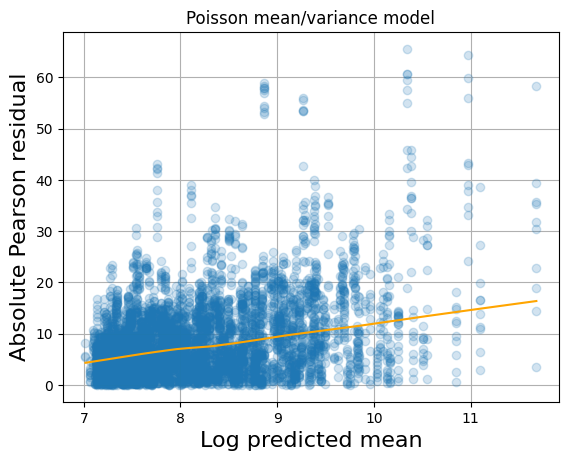

In [20]:
plt.clf()
plt.grid(True)
lfv = np.log(r2.fittedvalues).values
apr = np.abs(r2.resid_pearson)
ii = np.argsort(lfv)
lfv = lfv[ii]
apr = apr[ii]
ff = sm.nonparametric.lowess(apr, lfv)
plt.plot(lfv, apr, "o", alpha=0.2, rasterized=True)
plt.plot(ff[:, 0], ff[:, 1], "-", color="orange")
plt.title("Poisson mean/variance model")
plt.xlabel("Log predicted mean", size=16)
plt.ylabel("Absolute Pearson residual", size=16)

The Poisson variance model did not fit well based on the diagnostic plot above, so we next consider a Gamma family to better match the mean/variance relationship.

In [21]:
m3 = sm.GEE.from_formula("Births ~ RUCC_2013", groups="FIPS", offset="logPop",
                         family=sm.families.Gamma(link=sm.families.links.log()), data=da)
r3 = m3.fit(scale="X2")
r3.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                              Gamma   Mean cluster size:                 9.7
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Mon, 09 Feb 2026   Scale:                           0.032
Covariance type:                    robust   Time:                         14:32:00
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.4496      0.015   -289.565      0.000      -4.480      -4.419
RUCC_2013      0.0059      0.008      0.731      0.465      -0.010       0.022
==============================================================================
Skew:                          3.3220   Kurtosis:                      46.3145
Centered skew:                -8.0432   Centered kurtosis:            389.5965
==============================================================================
"""

Diagnostic plot for mean/variance relationship with gamma model.

Text(0, 0.5, 'Absolute Pearson residual')

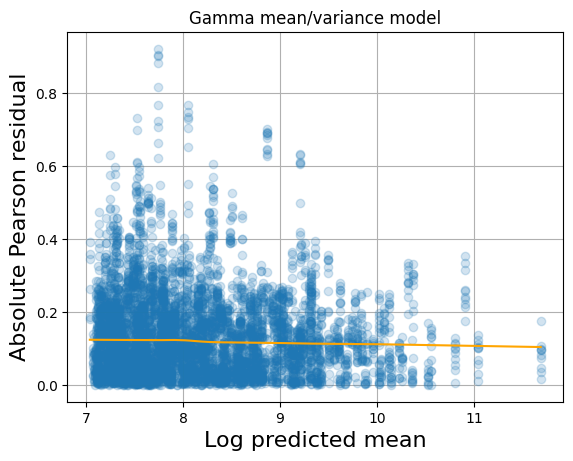

In [22]:
plt.clf()
plt.grid(True)
lfv = np.log(r3.fittedvalues).values
apr = np.abs(r3.resid_pearson)
ii = np.argsort(lfv)
lfv = lfv[ii]
apr = apr[ii]
ff = sm.nonparametric.lowess(apr, lfv)
plt.plot(lfv, apr, "o", alpha=0.2, rasterized=True)
plt.plot(ff[:, 0], ff[:, 1], "-", color="orange")
plt.title("Gamma mean/variance model")
plt.xlabel("Log predicted mean", size=16)
plt.ylabel("Absolute Pearson residual", size=16)

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


Text(0, 0.5, 'Absolute Pearson residual')

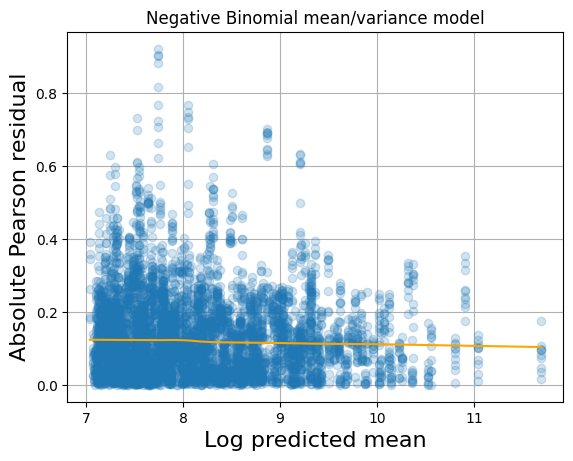

In [83]:
m_NB = sm.GEE.from_formula("Births ~ RUCC_2013", groups="FIPS", offset="logPop",
                         family=sm.families.Gamma(link=sm.families.links.log()), data=da)
r_NB = m_NB.fit(scale="X2")
r_NB.summary()

plt.clf()
plt.grid(True)
lfv = np.log(r_NB.fittedvalues).values
apr = np.abs(r_NB.resid_pearson)
ii = np.argsort(lfv)
lfv = lfv[ii]
apr = apr[ii]
ff = sm.nonparametric.lowess(apr, lfv)
plt.plot(lfv, apr, "o", alpha=0.2, rasterized=True)
plt.plot(ff[:, 0], ff[:, 1], "-", color="orange")
plt.title("Negative Binomial mean/variance model")
plt.xlabel("Log predicted mean", size=16)
plt.ylabel("Absolute Pearson residual", size=16)

Now we proceed to fit and interpret some regression models.  Here we use exchangeable correlation structure in the GEE.  Since RUCC and ADI are constant within groups, the parameter estimates and standard errors are the same as with the independence model.  The first model only considers the roles of urbanicity (RUCC) and deprivation (ADI).

In [23]:
m4 = sm.GEE.from_formula("Births ~ RUCC_2013 + logADINatRankZ", groups="FIPS", offset="logPop",
                         cov_struct=sm.cov_struct.Exchangeable(),
                         family=sm.families.Gamma(link=sm.families.links.log()), data=da)
r4 = m4.fit(scale="X2")
r4.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                              Gamma   Mean cluster size:                 9.7
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Mon, 09 Feb 2026   Scale:                           0.031
Covariance type:                    robust   Time:                         14:32:00
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.4227      0.016   -280.856      0.000      -4.454      -4.392
RUCC_2013         -0.0083      0.008     -0.984      0.325      -0.025       0.008
logADINatRankZ     0.0344      0.007      4.614      0.000       0.020       0.049
==============================================================================
Skew:                          5.0009   Kurtosis:                      48.8183
Centered skew:                -8.0432   Centered kurtosis:            389.5965
==============================================================================
"""

Now we consider the role of urbanicity as well as the potential for a linear time trend.

In [24]:
m5 = sm.GEE.from_formula("Births ~ RUCC_2013 + logADINatRankZ + year", groups="FIPS", offset="logPop",
                         cov_struct=sm.cov_struct.Exchangeable(),
                         family=sm.families.Gamma(link=sm.families.links.log()), data=da)
r5 = m5.fit(scale="X2")
r5.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                              Gamma   Mean cluster size:                 9.7
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Mon, 09 Feb 2026   Scale:                           0.031
Covariance type:                    robust   Time:                         14:32:00
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         11.0574      0.927     11.931      0.000       9.241      12.874
RUCC_2013         -0.0083      0.008     -0.985      0.325      -0.025       0.008
logADINatRankZ     0.0345      0.007      4.647      0.000       0.020       0.049
year              -0.0077      0.000    -16.729      0.000      -0.009      -0.007
==============================================================================
Skew:                          4.8764   Kurtosis:                      42.6261
Centered skew:                -8.8783   Centered kurtosis:            410.0012
==============================================================================
"""

Now we consider the possibility that the linear time trend is different based on the level of deprivation.

In [25]:
m6 = sm.GEE.from_formula("Births ~ (logADINatRankZ + RUCC_2013c) * yearc", groups="FIPS", offset="logPop",
                         cov_struct=sm.cov_struct.Exchangeable(),
                         family=sm.families.Gamma(link=sm.families.links.log()), data=da)
r6 = m6.fit(scale="X2")
r6.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                              Gamma   Mean cluster size:                 9.7
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Mon, 09 Feb 2026   Scale:                           0.031
Covariance type:                    robust   Time:                         14:32:01
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.4382      0.007   -621.042      0.000      -4.452      -4.424
logADINatRankZ           0.0346      0.007      4.653      0.000       0.020       0.049
RUCC_2013c              -0.0081      0.008     -0.959      0.338      -0.025       0.008
yearc                   -0.0077      0.000    -17.143      0.000      -0.009      -0.007
logADINatRankZ:yearc     0.0011      0.000      2.182      0.029       0.000       0.002
RUCC_2013c:yearc        -0.0032      0.001     -6.010      0.000      -0.004      -0.002
==============================================================================
Skew:                          4.8786   Kurtosis:                      42.7490
Centered skew:                -8.8106   Centered kurtosis:            404.3912
==============================================================================
"""

Score tests comparing pairs of nested models:

In [26]:
print(r5.model.compare_score_test(r4))
print(r6.model.compare_score_test(r5))

{'statistic': np.float64(177.05951675359339), 'df': 1, 'p-value': np.float64(0.0)}
{'statistic': np.float64(29.77633462819343), 'df': 2, 'p-value': np.float64(3.420984369117974e-07)}


In [61]:
m7 = sm.GEE.from_formula("Births ~ (logADINatRankZ + RUCC_2013c) * yearc", groups="FIPS", offset="logPop",
                         cov_struct=sm.cov_struct.Exchangeable(),
                         family=sm.families.NegativeBinomial(link=sm.families.links.log()), data=da)
r7 = m7.fit(scale="X2")
r7.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                   NegativeBinomial   Mean cluster size:                 9.7
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Wed, 11 Feb 2026   Scale:                           0.031
Covariance type:                    robust   Time:                         12:31:03
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.4382      0.007   -621.049      0.000      -4.452      -4.424
logADINatRankZ           0.0346      0.007      4.653      0.000       0.020       0.049
RUCC_2013c              -0.0081      0.008     -0.959      0.338      -0.025       0.008
yearc                   -0.0077      0.000    -17.143      0.000      -0.009      -0.007
logADINatRankZ:yearc     0.0011      0.000      2.182      0.029       0.000       0.002
RUCC_2013c:yearc        -0.0032      0.001     -6.010      0.000      -0.004      -0.002
==============================================================================
Skew:                          4.8784   Kurtosis:                      42.7464
Centered skew:                -8.8106   Centered kurtosis:            404.3873
==============================================================================
"""

## Principal Components Regression

We begin by double centering the demographic data.

In [27]:
demogx = np.asarray(demog)
demogx = np.log(1 + demogx)
demogx -= demogx.mean()
demogx -= demogx.mean(0)
demogx -= demogx.mean(1)[:, None]
demog

,A_H_F_0,A_H_F_1,A_H_F_2,A_H_F_3,A_H_F_4,A_H_F_5,A_H_F_6,A_H_F_7,A_H_F_8,A_H_F_9,...,W_N_M_10,W_N_M_11,W_N_M_12,W_N_M_13,W_N_M_14,W_N_M_15,W_N_M_16,W_N_M_17,W_N_M_18,W_N_M_19
FIPS,,,,,,,,,,,,,,,,,,,,,
01001,0,1,1,3,2,0,0,1,4,2,...,1608,1633,1540,1243,1074,790,586,397,180,56
01003,3,3,8,5,4,2,2,1,2,3,...,5911,6141,6263,6109,6099,4706,3185,2037,1031,419
01005,1,1,0,0,2,1,3,0,0,0,...,484,469,472,468,464,385,243,172,63,27
01007,0,2,0,0,1,0,1,0,2,0,...,656,725,605,528,503,350,241,129,75,20
01009,1,2,2,3,3,2,3,2,2,3,...,1852,1901,1859,1688,1573,1181,807,488,209,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56037,0,9,5,3,2,4,2,1,2,1,...,1093,1173,1420,1322,897,508,332,155,112,38
56039,1,4,1,1,2,1,3,1,0,0,...,758,654,721,744,656,394,221,136,85,24
56041,0,0,1,1,1,0,1,0,0,0,...,503,538,761,663,490,338,157,107,69,26


Get factors (principal components) from the demographic data.

In [28]:
u, s, vt = np.linalg.svd(demogx, 0)
v = vt.T

Convert the coefficients back to the original coordinates

In [29]:
def convert_coef(c, npc):
    return np.dot(v[:, 0:npc], c/s[0:npc])

Put the demographic factors into a dataframe

In [30]:
m = {("pc%02d" % k) : u[:, k] for k in range(100)}
m["FIPS"] = demog.index
demog_f = pd.DataFrame(m)

Merge demographic information into the births data

In [31]:
da = pd.merge(da, demog_f, on="FIPS", how="left")

Include this number of factors in subsequent models

In [32]:
npc = 10

A GLM, not appropriate since we have repeated measures on counties

In [33]:
fml = "Births ~ (logPopc + RUCC_2013c + logADINatRankZ) * yearc + " + " + ".join(["pc%02d" % j for j in range(npc)])
m7 = sm.GLM.from_formula(fml, family=sm.families.Poisson(), data=da)
r7 = m7.fit(scale="X2")
r7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 Births   No. Observations:                 5538
Model:                            GLM   Df Residuals:                     5520
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          55.711
Method:                          IRLS   Log-Likelihood:                -3200.0
Date:                Mon, 09 Feb 2026   Deviance:                   3.0134e+05
Time:                        14:32:05   Pearson chi2:                 3.08e+05
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                8.0838      0.008   1065.178      0.000       8.069       8.099
logPopc                  1.0223      0.002    423.488      0.000       1.018       1.027
RUCC_2013c               0.0086      0.003      2.918      0.004       0.003       0.014
logADINatRankZ           0.0187      0.002      9.101      0.000       0.015       0.023
yearc                   -0.0066      0.001    -10.288      0.000      -0.008      -0.005
logPopc:yearc           -0.0044      0.001     -7.955      0.000      -0.006      -0.003
RUCC_2013c:yearc        -0.0061      0.001     -6.741      0.000      -0.008      -0.004
logADINatRankZ:yearc     0.0017      0.000      4.014      0.000       0.001       0.003
pc00                    -2.0095      0.225     -8.947      0.000      -2.450      -1.569
pc01                     2.8109      0.188     14.972      0.000       2.443       3.179
pc02                     2.9104      0.090     32.251      0.000       2.734       3.087
pc03                    -3.8333      0.131    -29.278      0.000      -4.090      -3.577
pc04                    -0.0604      0.110     -0.549      0.583      -0.276       0.155
pc05                     2.9695      0.083     35.719      0.000       2.807       3.132
pc06                    -1.8577      0.130    -14.247      0.000      -2.113      -1.602
pc07                    -0.3114      0.134     -2.320      0.020      -0.574      -0.048
pc08                    -3.3047      0.174    -19.046      0.000      -3.645      -2.965
pc09                     0.8214      0.078     10.498      0.000       0.668       0.975
========================================================================================
"""

GEE accounts for the correlated data

In [75]:
m8 = sm.GEE.from_formula(fml, groups="FIPS",
         family=sm.families.NegativeBinomial(link=sm.families.links.log()), data=da)
r8 = m8.fit(scale="X2")
r8.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                   NegativeBinomial   Mean cluster size:                 9.7
Dependence structure:         Independence   Num. iterations:                     7
Date:                     Wed, 11 Feb 2026   Scale:                           0.169
Covariance type:                    robust   Time:                         12:37:14
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9231      0.129     53.671      0.000       6.670       7.176
pc00         -22.8289      4.474     -5.103      0.000     -31.598     -14.060
pc01          25.4288      3.016      8.432      0.000      19.518      31.339
pc02           2.2024      3.188      0.691      0.490      -4.046       8.451
pc03          -7.0666      1.858     -3.802      0.000     -10.709      -3.424
pc04         -12.7971      1.645     -7.779      0.000     -16.021      -9.573
pc05           3.1058      1.040      2.987      0.003       1.068       5.144
pc06          10.2573      1.594      6.436      0.000       7.134      13.381
pc07           5.5142      1.859      2.966      0.003       1.871       9.158
pc08           1.9557      2.091      0.935      0.350      -2.142       6.054
pc09          -3.8693      1.115     -3.472      0.001      -6.054      -1.685
pc10          -8.2960      1.230     -6.746      0.000     -10.706      -5.886
pc11           9.8157      1.026      9.570      0.000       7.805      11.826
pc12          -2.8845      1.251     -2.305      0.021      -5.337      -0.432
pc13           6.1789      1.170      5.282      0.000       3.886       8.472
pc14           2.9896      1.413      2.116      0.034       0.220       5.759
pc15           2.8140      1.523      1.847      0.065      -0.172       5.800
pc16          -4.3659      1.475     -2.961      0.003      -7.256      -1.476
pc17          -2.6419      1.280     -2.064      0.039      -5.151      -0.133
pc18          -6.3809      1.380     -4.624      0.000      -9.086      -3.676
pc19          -1.0507      1.163     -0.904      0.366      -3.330       1.228
pc20           0.2403      1.357      0.177      0.859      -2.419       2.900
pc21          -4.3344      1.350     -3.210      0.001      -6.981      -1.688
pc22          -0.7544      1.113     -0.678      0.498      -2.935       1.427
pc23          -1.7303      1.257     -1.377      0.169      -4.193       0.733
pc24           4.5500      1.031      4.412      0.000       2.529       6.571
pc25          -2.7255      1.495     -1.824      0.068      -5.655       0.204
pc26          -2.7773      1.737     -1.599      0.110      -6.182       0.627
pc27          -2.8303      1.204     -2.351      0.019      -5.190      -0.471
pc28          -0.1263      1.310     -0.096      0.923      -2.693       2.440
pc29          -0.4753      1.297     -0.366      0.714      -3.017       2.067
pc30          -4.2049      1.379     -3.049      0.002      -6.908      -1.502
pc31          -2.3193      1.656     -1.401      0.161      -5.564       0.926
pc32           0.9007      1.616      0.557      0.577      -2.266       4.068
pc33           2.6084      1.337      1.951      0.051      -0.012       5.228
pc34          -2.3939      1.489     -1.607      0.108      -5.313       0.525
pc35           1.7363      1.32

Use log population as an offset instead of a covariate

In [74]:
fml = "Births ~ " + " + ".join(["pc%02d" % j for j in range(npc)])
m9 = sm.GEE.from_formula(fml, groups="FIPS", offset="logPop",
         family=sm.families.NegativeBinomial(link=sm.families.links.log()), data=da)
r9 = m9.fit(scale="X2")
r9.summary()

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                   NegativeBinomial   Mean cluster size:                 9.7
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Wed, 11 Feb 2026   Scale:                           0.006
Covariance type:                    robust   Time:                         12:36:59
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.3842      0.023   -194.373      0.000      -4.428      -4.340
pc00           2.0919      0.852      2.455      0.014       0.422       3.762
pc01          -0.4561      0.578     -0.789      0.430      -1.590       0.677
pc02           4.2343      0.429      9.867      0.000       3.393       5.075
pc03          -1.6860      0.334     -5.049      0.000      -2.341      -1.031
pc04          -0.1773      0.376     -0.472      0.637      -0.914       0.559
pc05           3.6232      0.239     15.162      0.000       3.155       4.092
pc06          -0.9637      0.363     -2.658      0.008      -1.674      -0.253
pc07           0.0578      0.391      0.148      0.883      -0.709       0.825
pc08          -3.6679      0.394     -9.299      0.000      -4.441      -2.895
pc09           1.5838      0.209      7.579      0.000       1.174       1.993
pc10          -1.5758      0.228     -6.912      0.000      -2.023      -1.129
pc11           3.0893      0.233     13.237      0.000       2.632       3.547
pc12           0.6089      0.224      2.713      0.007       0.169       1.049
pc13           1.3452      0.253      5.322      0.000       0.850       1.841
pc14          -0.0247      0.265     -0.093      0.926      -0.544       0.495
pc15           1.2134      0.295      4.111      0.000       0.635       1.792
pc16          -2.5110      0.273     -9.199      0.000      -3.046      -1.976
pc17          -1.2430      0.210     -5.910      0.000      -1.655      -0.831
pc18          -0.8330      0.243     -3.428      0.001      -1.309      -0.357
pc19          -0.7322      0.265     -2.763      0.006      -1.252      -0.213
pc20          -0.5994      0.256     -2.345      0.019      -1.100      -0.098
pc21          -1.8447      0.271     -6.815      0.000      -2.375      -1.314
pc22          -0.2607      0.226     -1.155      0.248      -0.703       0.182
pc23          -0.8695      0.235     -3.708      0.000      -1.329      -0.410
pc24           0.5312      0.207      2.564      0.010       0.125       0.937
pc25          -0.5190      0.301     -1.726      0.084      -1.108       0.070
pc26           0.1998      0.308      0.649      0.516      -0.403       0.803
pc27          -0.7380      0.245     -3.009      0.003      -1.219      -0.257
pc28          -0.1330      0.253     -0.525      0.599      -0.629       0.363
pc29           0.1834      0.277      0.661      0.508      -0.360       0.727
pc30          -1.4560      0.307     -4.741      0.000      -2.058      -0.854
pc31           0.6806      0.282      2.413      0.016       0.128       1.233
pc32          -0.5399      0.259     -2.088      0.037      -1.047      -0.033
pc33          -0.1073      0.283     -0.379      0.705      -0.663       0.448
pc34           0.0294      0.289      0.102      0.919      -0.536       0.595
pc35           0.2010      0.29

Restructure the coefficients so that the age bands are in the columns.

In [36]:
def restructure(c):
    ii = pd.MultiIndex.from_tuples(na)
    c = pd.Series(c, index=ii)
    c = c.unstack()
    return c

This function fits a Gamma GLM to the data using 'npc' principal components as explanatory variables (using GEE to account for non-independence), then converts the coefficients back to the original variables.

In [69]:
def fitmodel(npc):
    # A GEE using log population as an offset
    fml = "Births ~ 1" if npc == 0 else "Births ~ RUCC_2013c*yearc + " + " + ".join(["pc%02d" % j for j in range(npc)])
    m = sm.GEE.from_formula(fml, groups="FIPS", family=sm.families.NegativeBinomial(link=sm.families.links.log()),
                            offset=da["logPop"], data=da)
    r = m.fit(scale="X2")

    # Convert the coefficients back to the original coordinates
    c = convert_coef(r.params[4:], npc)

    # Restructure the coefficients so that the age bands are
    # in the columns.
    c = restructure(c)

    return c, m, r

Plot styling information

In [70]:
colors = {"A": "purple", "B": "orange", "N": "lime", "W": "red"}
lt = {"F": "-", "M": ":"}
sym = {"H": "s", "N": "o"}
ages = range(0, 20)

Fit models with these numbers of PCs.

In [71]:
pcs = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

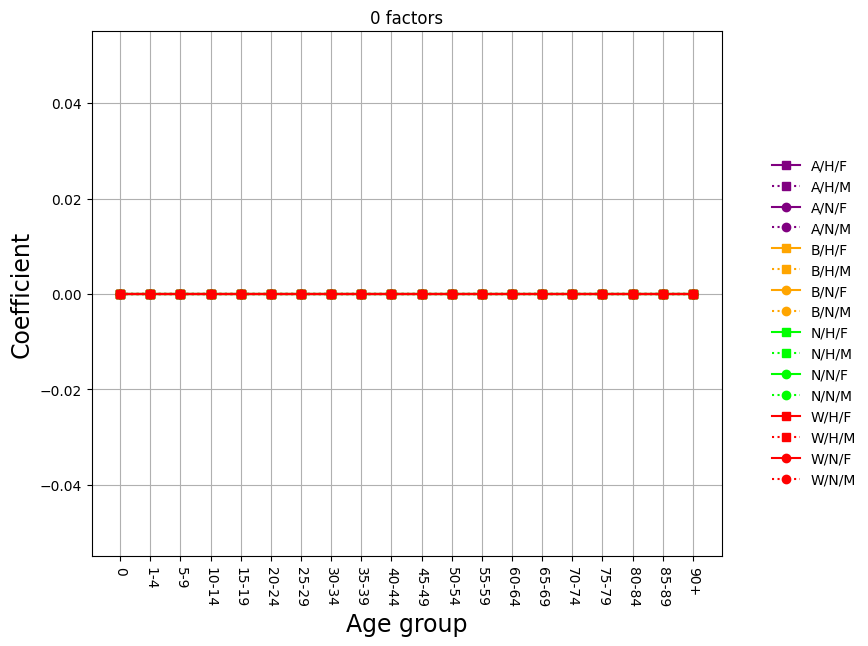

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

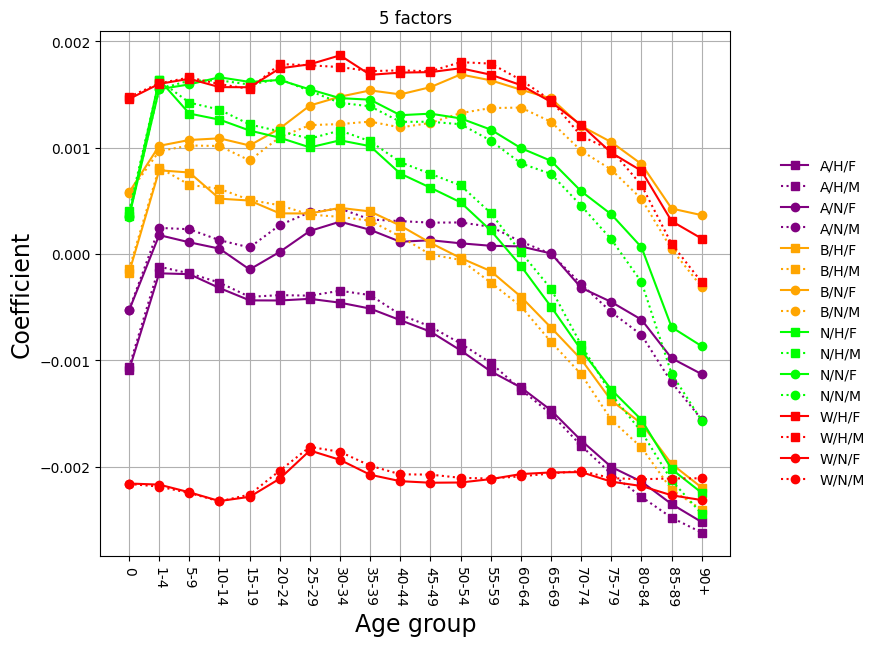

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

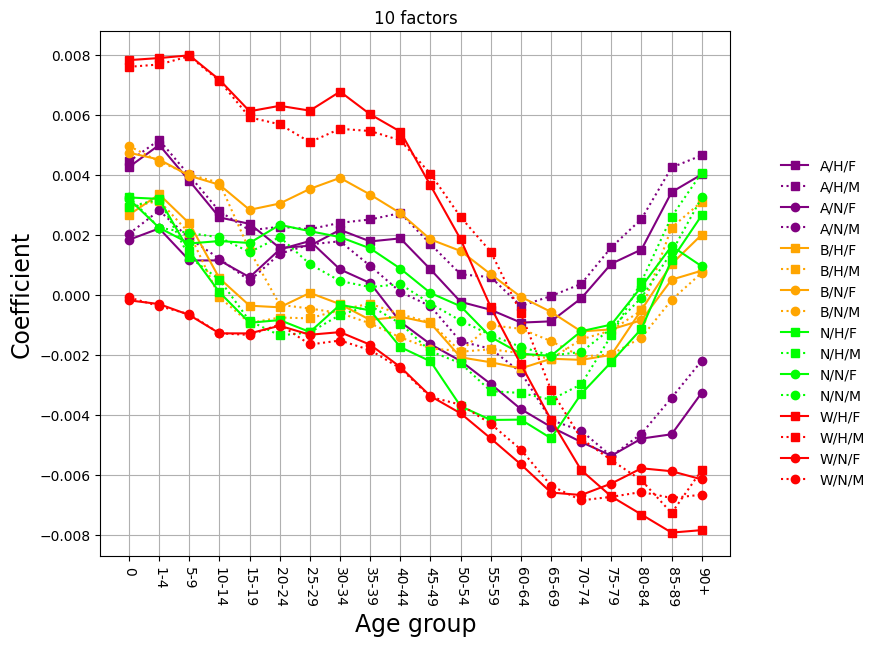

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

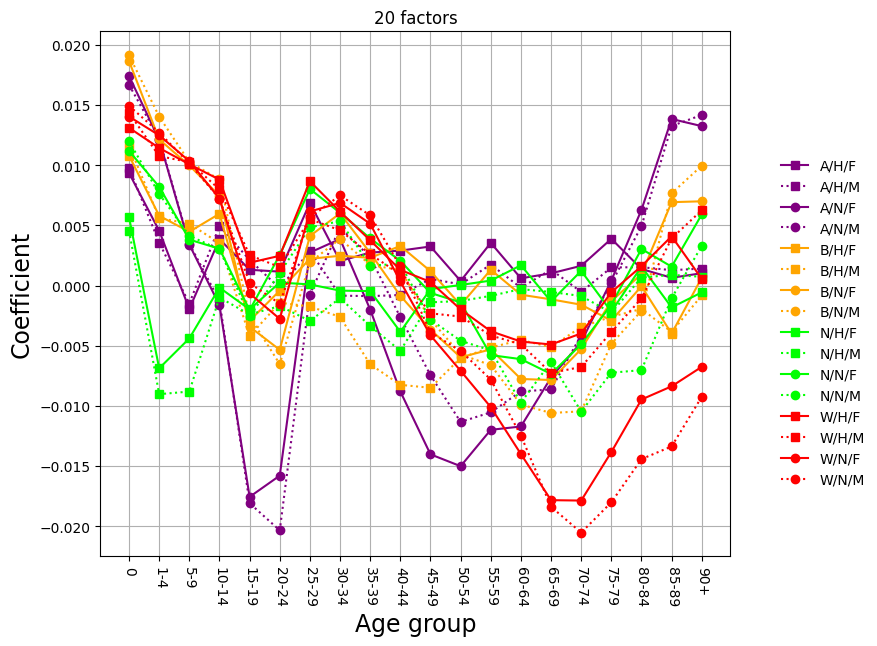

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

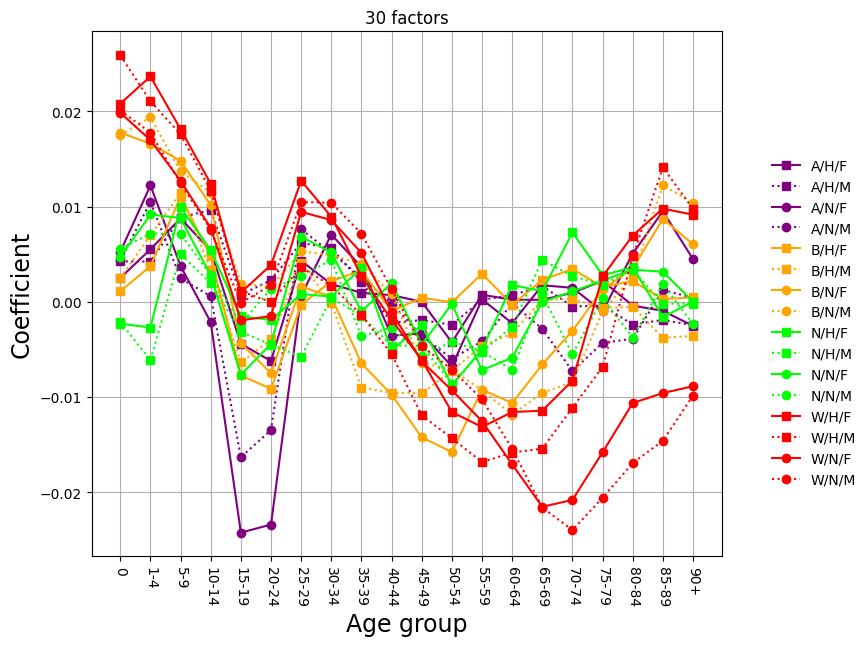

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

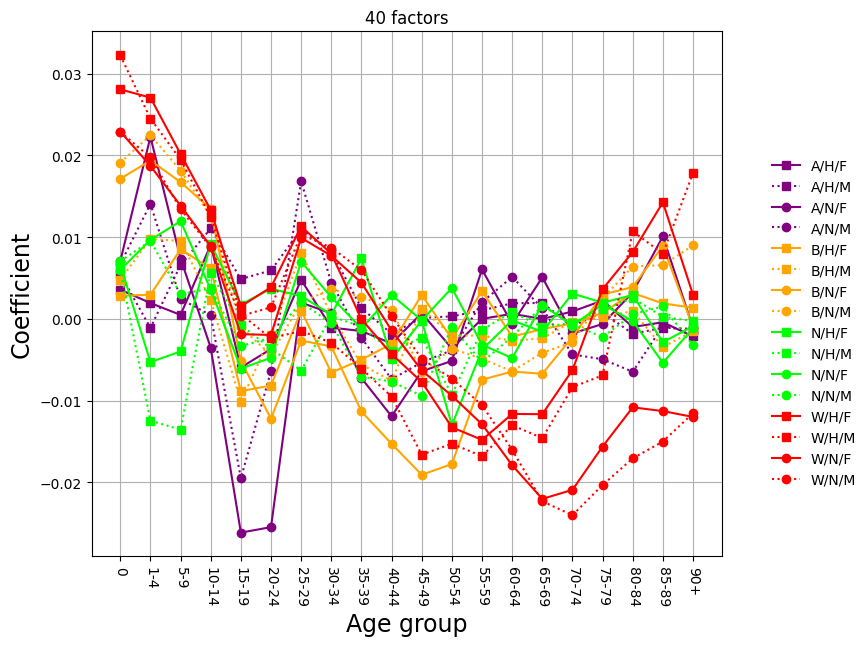

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

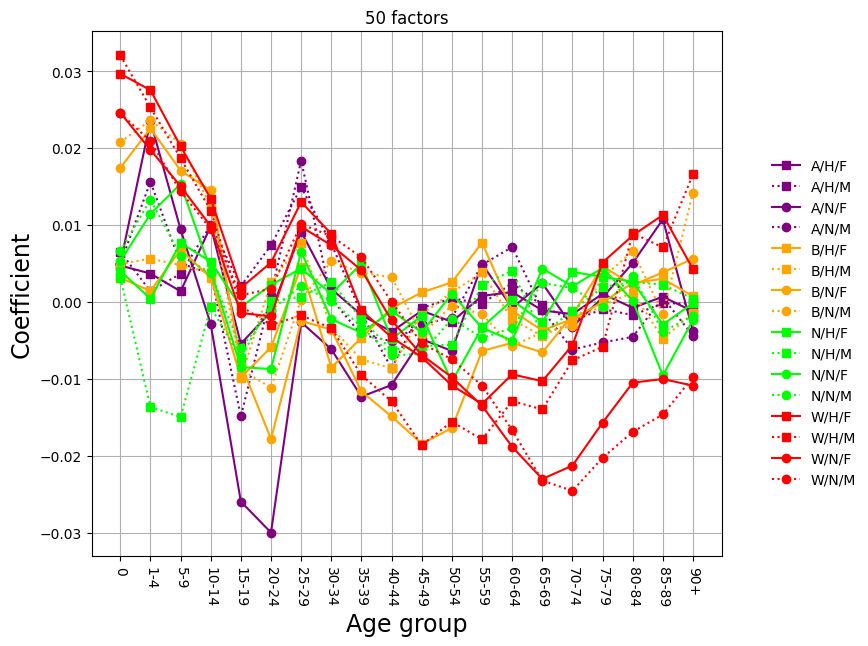

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

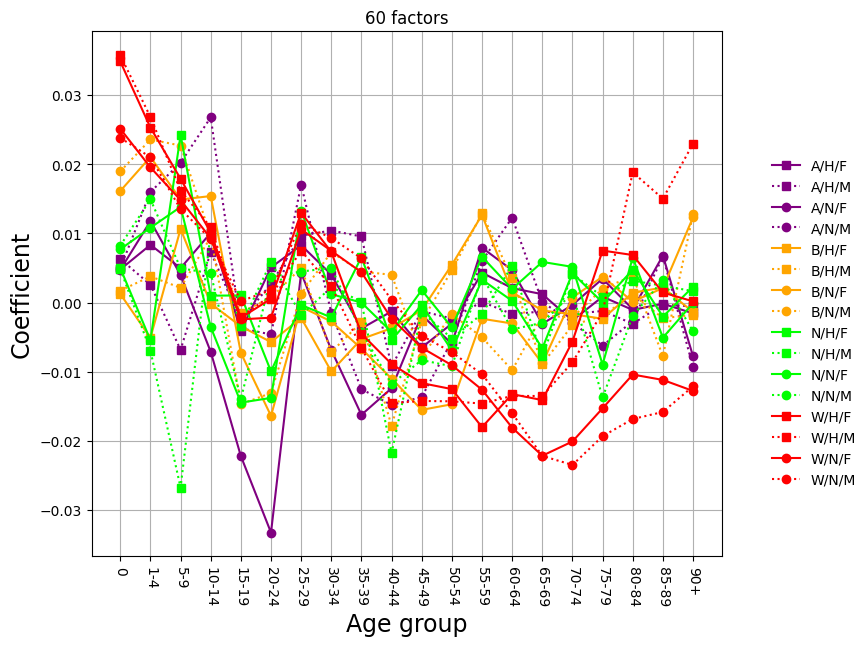

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

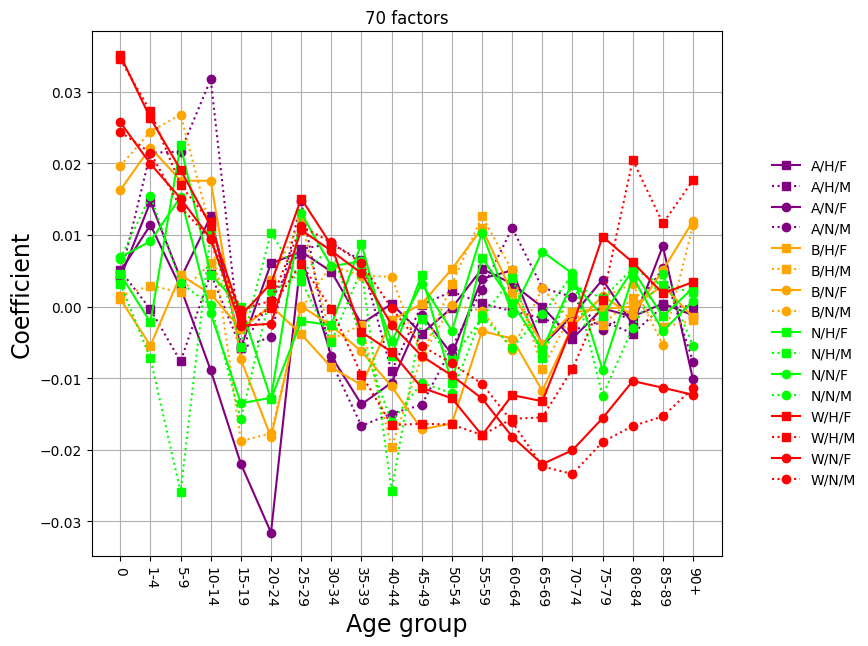

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

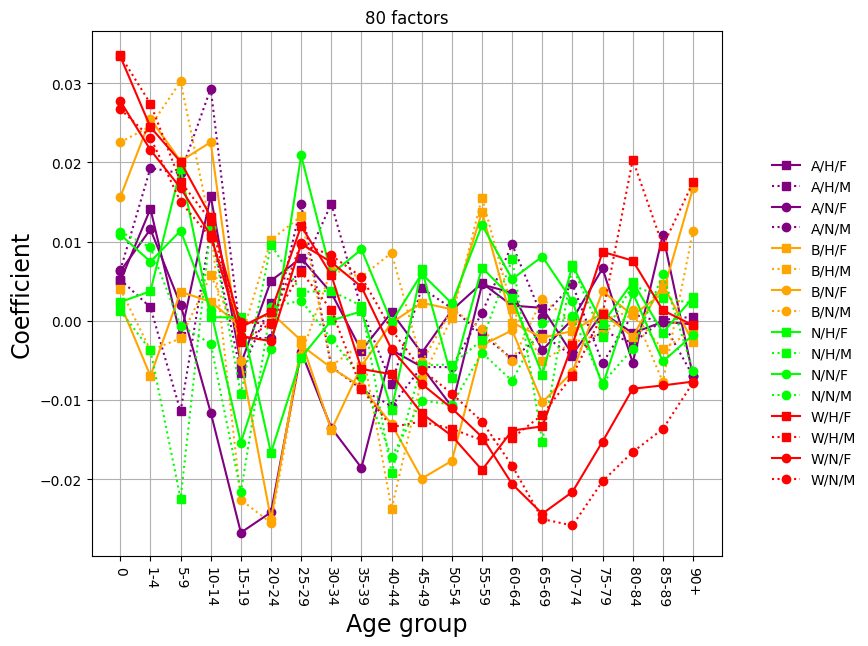

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

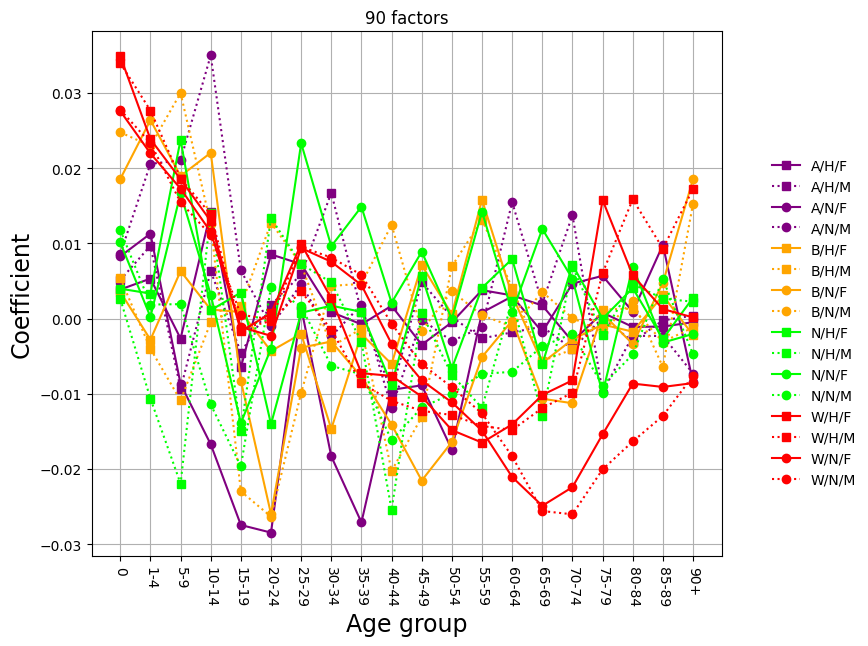

c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\venvs\si670\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<Figure size 640x480 with 0 Axes>

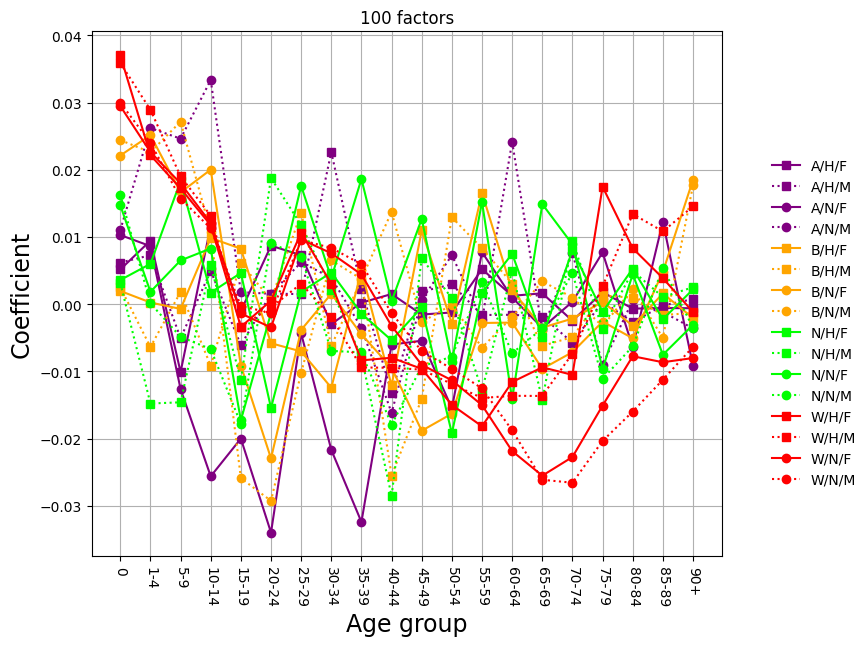

In [72]:
models = []
for npc in pcs:

    c, m, r = fitmodel(npc)
    models.append((m, r))

    plt.clf()
    plt.figure(figsize=(9, 7))
    ax = plt.axes([0.14, 0.18, 0.7, 0.75])
    ax.grid(True)
    for i in range(c.shape[0]):
        a = c.index[i]
        la = "/".join(a)
        ax.plot(ages, c.iloc[i, :], lt[a[2]] + sym[a[1]], color=colors[a[0]],
                label=la)

    # Setup the horizontal axis labels
    ax.set_xticks(ages)
    ax.set_xticklabels(age_groups)
    for x in plt.gca().get_xticklabels():
        x.set_rotation(-90)

    ha, lb = plt.gca().get_legend_handles_labels()
    leg = plt.figlegend(ha, lb, loc="center right")
    leg.draw_frame(False)

    plt.xlabel("Age group", size=17)
    plt.ylabel("Coefficient", size=17)
    plt.title("%d factors" % npc)
    plt.show()

Use score tests to get a sense of the number of PC factors to include; also consider the PVEs calculated above.

In [73]:
for k in range(10):
    st = models[k+1][0].compare_score_test(models[k][1])
    print("%d versus %d: p=%f" % (pcs[k+1], pcs[k], st["p-value"]))

5 versus 0: p=0.000000
10 versus 5: p=0.000000
20 versus 10: p=0.000000
30 versus 20: p=0.000000
40 versus 30: p=0.000054
50 versus 40: p=0.043846
60 versus 50: p=0.000035
70 versus 60: p=0.414722
80 versus 70: p=0.032346
90 versus 80: p=0.354754


  10290063776.6   10290063776.6             0.0
   6080896657.5   29409735613.6             0.8
   4941744213.7   16037289230.8             0.7
   5158914060.2    9303542748.0             0.4
   4734274210.0   10221488222.6             0.5
   4699747707.4    9856317537.9             0.5
   4600688104.8   10129861990.4             0.5
   4191582862.3   10056671437.1             0.6
   4150053552.4    9995401734.3             0.6
   4218731925.2    9574183207.3             0.6
                               GEE Regression Results                              
Dep. Variable:                      Births   No. Observations:                 5538
Model:                                 GEE   No. clusters:                      572
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                  10
Family:                   NegativeBinomial   Mean cluster size:                 9.7
Dependence struc

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_15716\1310740054.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  icept = res.params[0] + da["logPop"]
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_15716\1310740054.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  icept = res.params[0] + da["logPop"]


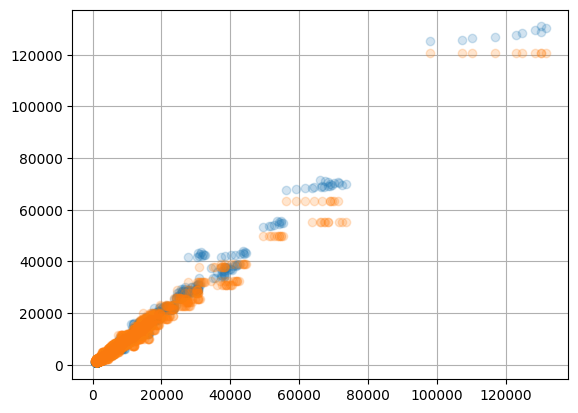

In [80]:
# https://www.jstor.org/stable/45118439

def dv(a, b, scale):
    return ((b-a)**2).sum()
    vpa = 2 * scale * a
    vpb = 2 * scale * b
    u = np.log(vpb + np.sqrt(1 + vpb**2)) - np.log(vpa + np.sqrt(1 + vpa**2))
    u += vpb * np.sqrt(1 + vpb**2) - vpa * np.sqrt(1 + vpa**2)
    return (u**2).sum()

for k in range(10):
    res = models[k][1]
    scale = res.scale
    n = len(res.model.endog)
    icept = res.params[0] + da["logPop"]
    numer = dv(res.model.endog, res.fittedvalues, scale)
    denom = dv(res.model.endog, np.exp(icept), scale)
    #assert(np.all(denom >= numer))
    r2 = 1 - numer / denom
    #print(denom)
    print("%15.1f %15.1f %15.1f" % (numer, denom, r2))
    #print(res.params[0])
  
print(res.summary())
res = models[5][1]
icept = res.params[0] + da["logPop"]
plt.plot(res.model.endog, res.fittedvalues, "o", alpha=0.2)
plt.plot(res.model.endog, np.exp(icept), "o", alpha=0.2)
plt.grid(True)